# Transformer Experiments for Multi-Label SDG Indicator Classification

## Introduction

In the previous experiments, different machine learning and deep learning methods were used for text classification. Most of these approaches required manually creating features using techniques such as TF-IDF and word embeddings before training models.

For this section, transformer models are explored for the same classification task. Transformer models are different because they use pretrained language representations that can learn contextual information directly from text instead of relying heavily on manual feature engineering.

The aim of these experiments is to understand how transformer-based approaches perform for multi-label SDG indicator classification and compare their performance across different experimental settings.

This notebook follows a complete workflow starting from understanding the dataset and exploring its characteristics, then preparing the data for transformer models, training different transformer architectures, and finally evaluating their performance.

The main stages followed in this notebook include:

- Understanding the dataset structure and contents
- Performing exploratory data analysis (EDA)
- Cleaning and preparing text data
- Creating multi-label targets for classification
- Preparing transformer inputs using tokenization
- Fine-tuning pretrained transformer models
- Evaluating performance using classification metrics
- Comparing results across multiple experiments

The objective is not only to build models with good performance, but also to understand how transformer-based methods behave when applied to multi-label text classification problems.

# STEP 1: Import Libraries

We import the required libraries for:

- data handling
- preprocessing
- transformers
- evaluation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (classification_report, f1_score, accuracy_score, hamming_loss)

from transformers import (AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments)
from datasets import Dataset
import torch

import re
from bs4 import BeautifulSoup

# STEP 2: Load Dataset

We load training and testing datasets.

We inspect their structure before preprocessing.

In [2]:
train_df = pd.read_csv( "/content/Devex_train.csv", encoding="latin1" )
test_df = pd.read_csv("/content/Devex_test_questions.csv", encoding="latin1")

train_df.head()

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# STEP 3: Understanding Dataset Structure

We inspect:

- available columns
- label columns
- text columns
- metadata columns

In [3]:
train_df.info()
train_df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2995 entries, 0 to 2994
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique ID  2995 non-null   int64  
 1   Type       2995 non-null   object 
 2   Text       2995 non-null   object 
 3   Label 1    2995 non-null   object 
 4   Label 2    1635 non-null   object 
 5   Label 3    738 non-null    object 
 6   Label 4    312 non-null    object 
 7   Label 5    142 non-null    object 
 8   Label 6    59 non-null     object 
 9   Label 7    21 non-null     object 
 10  Label 8    10 non-null     object 
 11  Label 9    4 non-null      object 
 12  Label 10   2 non-null      object 
 13  Label 11   0 non-null      float64
 14  Label 12   0 non-null      float64
dtypes: float64(2), int64(1), object(12)
memory usage: 351.1+ KB


Index(['Unique ID', 'Type', 'Text', 'Label 1', 'Label 2', 'Label 3', 'Label 4',
       'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10',
       'Label 11', 'Label 12'],
      dtype='object')

In [4]:
label_cols=[
f"Label {i}"
for i in range(1,13)
]

print (label_cols)

['Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label 6', 'Label 7', 'Label 8', 'Label 9', 'Label 10', 'Label 11', 'Label 12']


# STEP 4: Building Target Labels

Each document may belong to multiple indicators.

We combine indicator labels into one list.

In [5]:
train_df["labels"]=train_df[
label_cols
].apply(
lambda row: [v for v in row if pd.notna(v)],
axis=1
)

train_df.head(10)

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12,labels
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.b.2 - Total net official development assist...
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.b.2 - Total net official development assist...
2,23168,Organization,Catholic Health Association of India (CHAI): <...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.d.1 - International Health Regulations (IHR...
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.4.1 - Mortality rate attributed to cardiova...
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.3.5 - Number of people requiring interventi...
5,51151,Funding Info,Egypt Country Programme For Family Planning (2...,3.7.1 - Proportion of women of reproductive ag...,3.7.2 - Adolescent birth rate (aged 10_14 year...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.7.1 - Proportion of women of reproductive a...
6,12265,Grant,Improving Quantification and Forecasting of Ne...,3.b.3 - Proportion of health facilities that h...,3.b.2 - Total net official development assista...,"3.3.2 - Tuberculosis incidence per 100,000 pop...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.b.3 - Proportion of health facilities that ...
7,14446,Grant,Call for Metrology for Emerging Radiopharmaceu...,3.b.2 - Total net official development assista...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.b.2 - Total net official development assist...
8,14000,Grant,Funding to Stimulate Clinical and Translationa...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.b.2 - Total net official development assist...
9,280626,Tender,Procurement of Radiopharmaceuticals for Treatm...,3.4.1 - Mortality rate attributed to cardiovas...,3.8.1 - Coverage of essential health services ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.4.1 - Mortality rate attributed to cardiova...


In [6]:
TEXT_COL="Text"

# Missing Values Analysis

We inspect missing values before preprocessing.

In [7]:
train_df.isnull().sum()

,0
Unique ID,0
Type,0
Text,0
Label 1,0
Label 2,1360
Label 3,2257
Label 4,2683
Label 5,2853
Label 6,2936
Label 7,2974


# Label Distribution

We inspect how indicators are distributed.

This helps detect imbalance.

In [8]:
all_labels=[]

for x in train_df["labels"]:
    all_labels.extend(x)

pd.Series(
all_labels
).value_counts().head(20)

,count
3.b.2 - Total net official development assistance to medical research and basic health sector,1044
"3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)",531
"3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease",485
3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis,397
"3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations",372
3.2.1 - Under-5 mortality rate,249
3.c.1 - Health worker density and distribution,232
"3.9.2 - Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (exposure to unsafe Water, Sanitation and Hygiene for All (WASH) services)",218
3.1.1 - Maternal mortality ratio,218
3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness,217


# Indicators Per Document

Documents may have multiple indicators.

We inspect how many labels appear per sample.

In [9]:
train_df["num_labels"]=train_df[
"labels"
].apply(len)

train_df["num_labels"].describe()

,num_labels
count,2995.000000
mean,1.975960
std,1.230902
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,10.000000


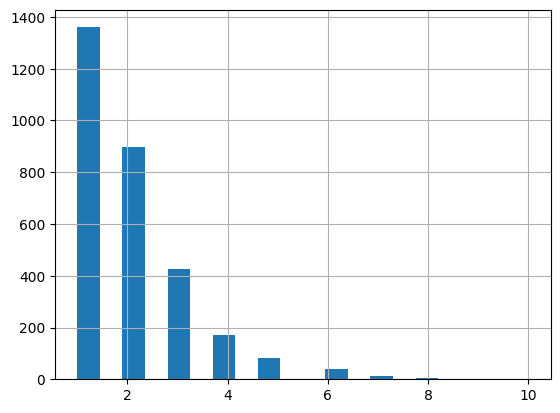

In [10]:
train_df["num_labels"].hist(bins=20)

plt.show()

# Text Length Analysis

Transformer models have sequence limits.

We inspect document lengths.

In [11]:
train_df["text_length"]=train_df[
TEXT_COL
].apply(
lambda x:
len(str(x).split())

)

In [12]:
train_df["text_length"].describe()

,text_length
count,2995.000000
mean,477.745242
std,641.966053
min,2.000000
25%,18.000000
50%,211.000000
75%,618.500000
max,3781.000000


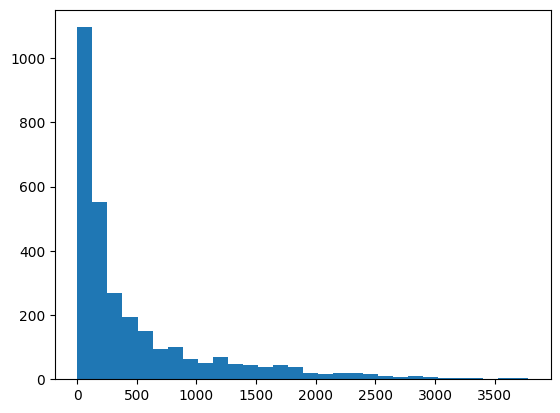

In [13]:
plt.hist(
train_df["text_length"],
bins=30
)

plt.show()

In [14]:
train_df.sort_values(
"text_length",
ascending=False
)[[TEXT_COL]].head()

,Text
836,Alzheimer's Disease Research Centers ; ; ; ...
1237,Model Organisms Screening Center for the Undia...
2637,International Collaborative Research on Drug A...
1396,Advancing the Science of Geriatric Palliative ...
190,International Research Collaboration on Drug A...


In [15]:
duplicates=train_df.duplicated(
subset=[TEXT_COL]
).sum()

print(duplicates)

33


# STEP 5: Cleaning

Only minimal cleaning is performed.

We preserve natural language because pretrained transformers learn from natural text.

In [16]:
def clean_text(text):
    text = str(text)

    # Strip HTML tags
    soup = BeautifulSoup(text, 'html.parser')
    text = soup.get_text(separator=' ')

    # Remove URLs
    text = re.sub(r'https?://\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove leftover HTML entities
    text = re.sub(r'&[a-z]+;', ' ', text)

    # Replace whitespace
    text = text.replace('\xa0', ' ')

    # Collapse all whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


train_df[TEXT_COL]=train_df[
TEXT_COL
].apply(clean_text)

#remove empty text

train_df=train_df[
train_df[TEXT_COL].str.len()>0
]

#remove duplictes

train_df=train_df.drop_duplicates(
subset=[TEXT_COL]
)

#apply on test dataset too
test_df[TEXT_COL] = test_df[TEXT_COL].apply(clean_text)

train_df.head(5)

,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12,labels,num_labels,text_length
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.b.2 - Total net official development assist...,2,398
1,14108,Grant,Research on Regenerative Medicine Introduction...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.b.2 - Total net official development assist...,1,313
2,23168,Organization,Catholic Health Association of India (CHAI): T...,3.d.1 - International Health Regulations (IHR)...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.d.1 - International Health Regulations (IHR...,4,313
3,219512,Contract,Quality Improvement Initiatives for Diabetes,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.4.1 - Mortality rate attributed to cardiova...,1,5
4,274093,Tender,Provision of Thalassemia Drugs and Disposables...,3.3.5 - Number of people requiring interventio...,3.4.1 - Mortality rate attributed to cardiovas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[3.3.5 - Number of people requiring interventi...,2,513


# STEP 6: Label Encoding

Multi-label targets are converted into binary vectors.

In [17]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(train_df["labels"])

# See the shape of the binary matrix
print("Shape of y:", y.shape)

# See what the 27 class names are
print("\nClass names (the 27 indicators):")
for i, name in enumerate(mlb.classes_):
    print(f"  {i:>2}: {name[:60]}")

# See the binary matrix for the first 5 documents
print("\nFirst 5 rows of y (binary label matrix):")
print(y[:5])

# Cross-check: show the original labels of doc 0 and its encoded vector
print("\nDoc 0 original labels:", train_df['labels'].iloc[0])
print("Doc 0 encoded vector :", y[0])

Shape of y: (2961, 27)

Class names (the 27 indicators):
   0: 3.1.1 - Maternal mortality ratio
   1: 3.1.2 - Proportion of births attended by skilled health pers
   2: 3.2.1 - Under-5 mortality rate
   3: 3.2.2 - Neonatal mortality rate
   4: 3.3.1 - Number of new HIV infections per 1,000 uninfected po
   5: 3.3.2 - Tuberculosis incidence per 100,000 population
   6: 3.3.3 - Malaria incidence per 1,000 population
   7: 3.3.4 - Hepatitis B incidence per 100,000 population
   8: 3.3.5 - Number of people requiring interventions against neg
   9: 3.4.1 - Mortality rate attributed to cardiovascular disease,
  10: 3.4.2 - Suicide mortality rate
  11: 3.5.1 - Coverage of treatment interventions (pharmacological
  12: 3.5.2 - Harmful use of alcohol, defined according to the nat
  13: 3.6.1 - Death rate due to road traffic injuries
  14: 3.7.1 - Proportion of women of reproductive age (aged 15_49 
  15: 3.7.2 - Adolescent birth rate (aged 10_14 years; aged 15_19 
  16: 3.8.1 - Coverage of esse

In [18]:
# train-test splitting
X_train, X_test, y_train, y_test = train_test_split(
train_df[TEXT_COL],
y,
test_size=0.2,
random_state=42
)

# STEP 7: Tokenization

Text is converted into transformer input representations.

In [19]:
#experiment 1

tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")
train_encodings=tokenizer(
X_train.tolist(),
padding="max_length",
truncation=True,
max_length=256

)

test_encodings=tokenizer(
X_test.tolist(),
padding="max_length",
truncation=True,
max_length=256
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [20]:
#Dataset Conversion

train_dataset=Dataset.from_dict({
**train_encodings,
"labels": y_train.astype(np.float32)
})

test_dataset=Dataset.from_dict({
**test_encodings,
"labels": y_test.astype(np.float32)
})

In [21]:
#model

model=AutoModelForSequenceClassification.from_pretrained(
"bert-base-uncased",
num_labels=y.shape[1],
problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# STEP 8: Model Training

We fine tune pretrained transformer models.

In [22]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    fp16=True,
    report_to="none"
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [23]:
# compute pos_weight from training labels
n_pos = y_train.sum(axis=0).astype(float)
n_neg = y_train.shape[0] - n_pos
pos_weight = np.clip(n_neg / np.maximum(n_pos, 1), 1.0, 50.0)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32)

# compute_metrics so evaluation shows real metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        "hamming_loss": hamming_loss(labels, preds),
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
    }

# custom Trainer with weighted loss
class WeightedTrainer(Trainer):
    def __init__(self, *args, pos_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.BCEWithLogitsLoss(
            pos_weight=self.pos_weight.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    pos_weight=pos_weight_tensor
)

trainer.train()

Epoch,Training Loss,Validation Loss,Hamming Loss,F1 Micro,F1 Macro,Runtime,Samples Per Second,Steps Per Second
1,1.188873,1.029389,0.327525,0.264516,0.237563,2.552200,232.345000,14.889000
2,0.780931,0.758052,0.158703,0.426540,0.411057,2.828700,209.637000,13.434000
3,0.631985,0.678628,0.118106,0.489609,0.468526,2.777800,213.480000,13.680000
4,0.524756,0.622037,0.112922,0.507893,0.483951,2.830300,209.516000,13.426000
5,0.442246,0.642969,0.086815,0.559290,0.545490,2.831300,209.446000,13.422000
6,0.378170,0.607487,0.081382,0.576536,0.548123,2.830200,209.528000,13.427000
7,0.350710,0.630362,0.077447,0.588859,0.571048,2.827700,209.710000,13.438000
8,0.291626,0.622806,0.071076,0.609472,0.586850,2.866300,206.885000,13.257000
9,0.283865,0.615118,0.069577,0.612387,0.579264,2.787100,212.765000,13.634000
10,0.284553,0.623587,0.067516,0.619768,0.591565,2.859800,207.357000,13.288000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=2960, training_loss=0.5441706838640007, metrics={'train_runtime': 1034.7719, 'train_samples_per_second': 22.884, 'train_steps_per_second': 2.861, 'total_flos': 3115934156390400.0, 'train_loss': 0.5441706838640007, 'epoch': 10.0})

# STEP 9: Evaluation

We evaluate multi-label prediction performance.

In [24]:
predictions = trainer.predict(
test_dataset
)

In [25]:
probs = 1 / (1 + np.exp(-predictions.predictions))
preds = (probs >= 0.5).astype(int)

In [26]:
print(
"classification report"
)

print(classification_report(y_test, preds,
      target_names=[c.split(" - ")[0] for c in mlb.classes_],
      zero_division=0))

classification report
              precision    recall  f1-score   support

       3.1.1       0.46      0.83      0.59        42
       3.1.2       0.20      0.72      0.31        18
       3.2.1       0.50      0.82      0.62        44
       3.2.2       0.31      0.72      0.43        25
       3.3.1       0.62      0.89      0.73        64
       3.3.2       0.76      0.97      0.85        32
       3.3.3       0.67      0.94      0.78        36
       3.3.4       0.43      0.67      0.52         9
       3.3.5       0.48      0.85      0.61        41
       3.4.1       0.64      0.89      0.75       103
       3.4.2       0.34      0.79      0.48        14
       3.5.1       0.41      0.78      0.54        18
       3.5.2       0.33      0.83      0.48        12
       3.6.1       0.38      0.62      0.48         8
       3.7.1       0.56      0.82      0.67        39
       3.7.2       0.55      0.83      0.66        35
       3.8.1       0.42      0.56      0.48       104
     

In [27]:
print(
"micro f1",
f1_score(
y_test,
preds,
average="micro"
))

micro f1 0.576910569105691


In [28]:
print(
"hamming",
hamming_loss(
y_test,
preds
))

hamming 0.08125663606270689


In [29]:
exp1_results = {
    "experiment": "E1 - BERT-base, max_length=256, epochs=10, threshold=0.5",
    "hamming_loss": hamming_loss(y_test, preds),
    "f1_micro": f1_score(y_test, preds, average="micro", zero_division=0),
    "f1_macro": f1_score(y_test, preds, average="macro", zero_division=0),
    "f1_samples": f1_score(y_test, preds, average="samples", zero_division=0),
}
print(exp1_results)
results_log = [exp1_results]


{'experiment': 'E1 - BERT-base, max_length=256, epochs=10, threshold=0.5', 'hamming_loss': 0.08125663606270689, 'f1_micro': 0.576910569105691, 'f1_macro': 0.5486348138018092, 'f1_samples': 0.6295370073169895}


##EXPERIMENT 2 — BERT-base, max_length=512 (longer context)
Motivation: capture as much  tokens as possible for better training
Benefit: better context and learning of patterns
Risk: more computataion and slow training

In [30]:
MAX_LENGTH_E2 = 512

tokenizer_e2 = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings_e2 = tokenizer_e2(
    X_train.tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH_E2
)

test_encodings_e2 = tokenizer_e2(
    X_test.tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH_E2
)

train_dataset_e2 = Dataset.from_dict({
    **train_encodings_e2,
    "labels": y_train.astype(np.float32)
})

test_dataset_e2 = Dataset.from_dict({
    **test_encodings_e2,
    "labels": y_test.astype(np.float32)
})

model_e2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=y.shape[1],
    problem_type="multi_label_classification"
)

training_args_e2 = TrainingArguments(
    output_dir="./results_e2",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    fp16=True,
    report_to="none"
)

trainer_e2 = WeightedTrainer(
    model=model_e2,
    args=training_args_e2,
    train_dataset=train_dataset_e2,
    eval_dataset=test_dataset_e2,
    compute_metrics=compute_metrics,
    pos_weight=pos_weight_tensor
)

trainer_e2.train()

# Evaluate
preds_output_e2 = trainer_e2.predict(test_dataset_e2)
probs_e2 = 1 / (1 + np.exp(-preds_output_e2.predictions))
preds_e2 = (probs_e2 >= 0.5).astype(int)

exp2_results = {
    "experiment": "E2 - BERT-base, max_length=512, epochs=10, threshold=0.5",
    "hamming_loss": hamming_loss(y_test, preds_e2),
    "f1_micro": f1_score(y_test, preds_e2, average="micro", zero_division=0),
    "f1_macro": f1_score(y_test, preds_e2, average="macro", zero_division=0),
    "f1_samples": f1_score(y_test, preds_e2, average="samples", zero_division=0),
}
print(exp2_results)
results_log.append(exp2_results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Hamming Loss,F1 Micro,F1 Macro,Runtime,Samples Per Second,Steps Per Second
1,1.243893,1.168785,0.456124,0.187020,0.171106,5.320200,111.462000,3.571000
2,1.047067,0.859820,0.260571,0.318523,0.287794,5.407500,109.663000,3.514000
3,0.775392,0.727816,0.170633,0.418228,0.403591,5.568800,106.486000,3.412000
4,0.674847,0.668158,0.152208,0.442206,0.418753,5.346900,110.906000,3.553000
5,0.560514,0.628696,0.121916,0.498458,0.466176,5.523000,107.369000,3.440000
6,0.511205,0.597502,0.108301,0.521787,0.488404,5.370100,110.425000,3.538000
7,0.450308,0.590627,0.091562,0.561341,0.531487,5.527400,107.283000,3.437000
8,0.420603,0.573507,0.093561,0.556805,0.520723,5.492000,107.976000,3.460000
9,0.395603,0.569447,0.088564,0.570823,0.532513,7.194100,82.429000,2.641000
10,0.375404,0.576020,0.084442,0.580385,0.542973,5.315200,111.567000,3.575000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

{'experiment': 'E2 - BERT-base, max_length=500, epochs=10, threshold=0.5', 'hamming_loss': 0.08862656923365186, 'f1_micro': 0.5703905540417802, 'f1_macro': 0.5323178189087814, 'f1_samples': 0.6250903700766335}


## EXPERIMENT 3 — BERT-base, max_length=256, epochs=5,
              per-label threshold tuning
Motivation 1: more epochs may improve on 3-epoch convergence.
Motivation 2: threshold=0.5 hurts rare labels. Per-label
             thresholds found by searching [0.1, 0.9] on
            the validation set reduce this gap.

In [ ]:


model_e3 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=y.shape[1],
    problem_type="multi_label_classification"
)

training_args_e3 = TrainingArguments(
    output_dir="./results_e3",
    num_train_epochs=15,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    fp16=True,
    report_to="none"
)

trainer_e3 = WeightedTrainer(
    model=model_e3,
    args=training_args_e3,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    pos_weight=pos_weight_tensor
)

trainer_e3.train()

# Get probability outputs for threshold tuning
preds_output_e3 = trainer_e3.predict(test_dataset)
probs_e3 = 1 / (1 + np.exp(-preds_output_e3.predictions))

best_thresholds = np.full(y.shape[1], 0.5)

print("Tuning per-label thresholds...")
for label_idx in range(y.shape[1]):
    best_hl   = float("inf")
    best_t    = 0.5
    for t in np.arange(0.05, 0.96, 0.05):
        col_pred = (probs_e3[:, label_idx] >= t).astype(int)
        hl = np.mean(col_pred != y_test[:, label_idx])
        if hl < best_hl:
            best_hl = hl
            best_t  = t
    best_thresholds[label_idx] = best_t

print("Optimal thresholds per label:")
for code, t in zip([c.split(" - ")[0] for c in mlb.classes_], best_thresholds):
    print(f"  {code:>6}: {t:.2f}")

# Apply tuned thresholds
preds_e3_tuned = (probs_e3 >= best_thresholds).astype(int)

exp3_results = {
    "experiment": "E3 - BERT-base, max_length=256, epochs=15, per-label threshold",
    "hamming_loss": hamming_loss(y_test, preds_e3_tuned),
    "f1_micro": f1_score(y_test, preds_e3_tuned, average="micro", zero_division=0),
    "f1_macro": f1_score(y_test, preds_e3_tuned, average="macro", zero_division=0),
    "f1_samples": f1_score(y_test, preds_e3_tuned, average="samples", zero_division=0),
}
print(exp3_results)
results_log.append(exp3_results)

# Also evaluate with global 0.5 for comparison (to isolate threshold effect)
preds_e3_global = (probs_e3 >= 0.5).astype(int)
print("\nFor reference — same model with global threshold 0.5:")
print({
    "hamming_loss": round(hamming_loss(y_test, preds_e3_global), 4),
    "f1_macro": round(f1_score(y_test, preds_e3_global, average="macro", zero_division=0), 4),
})

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Hamming Loss,F1 Micro,F1 Macro,Runtime,Samples Per Second,Steps Per Second
1,1.241184,1.176250,0.402910,0.202694,0.173176,2.811300,210.936000,13.517000
2,0.836088,0.789099,0.188995,0.388687,0.369181,2.857200,207.545000,13.300000
3,0.654614,0.679566,0.121979,0.488342,0.465102,2.814800,210.669000,13.500000
4,0.549692,0.623095,0.102617,0.534429,0.503635,2.847000,208.291000,13.347000
5,0.454251,0.638280,0.081069,0.576094,0.547263,2.843600,208.535000,13.363000
6,0.377611,0.609856,0.077197,0.593955,0.557576,2.834200,209.229000,13.408000
7,0.335752,0.649536,0.071014,0.605893,0.584828,2.779600,213.339000,13.671000
8,0.262803,0.635102,0.068578,0.611740,0.589120,2.852800,207.862000,13.320000
9,0.243908,0.645847,0.066767,0.617805,0.594957,2.804500,211.447000,13.550000
10,0.231279,0.653087,0.062894,0.628824,0.599679,2.861000,207.270000,13.282000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Tuning per-label thresholds...
Optimal thresholds per label:
   3.1.1: 0.90
   3.1.2: 0.95
   3.2.1: 0.85
   3.2.2: 0.95
   3.3.1: 0.80
   3.3.2: 0.75
   3.3.3: 0.75
   3.3.4: 0.90
   3.3.5: 0.75
   3.4.1: 0.70
   3.4.2: 0.90
   3.5.1: 0.95
   3.5.2: 0.95
   3.6.1: 0.70
   3.7.1: 0.85
   3.7.2: 0.95
   3.8.1: 0.70
   3.8.2: 0.85
   3.9.1: 0.95
   3.9.2: 0.85
   3.9.3: 0.95
   3.a.1: 0.95
   3.b.1: 0.85
   3.b.2: 0.75
   3.b.3: 0.85
   3.c.1: 0.90
   3.d.1: 0.95
{'experiment': 'E3 - BERT-base, max_length=256, epochs=5, per-label threshold', 'hamming_loss': 0.04297045781025545, 'f1_micro': 0.6416666666666667, 'f1_macro': 0.6116139384411999, 'f1_samples': 0.6508724926937406}

For reference — same model with global threshold 0.5:
{'hamming_loss': 0.0763, 'f1_macro': 0.5618}


##comaprison tabel

In [32]:
# RESULTS COMPARISON TABLE

print(f"\n{'='*95}")
print(f"{'Experiment':<50} {'HL':>7} {'F1-micro':>9} {'F1-macro':>9} {'F1-samp':>9}")
print(f"{'='*95}")

best_hl = min(r["hamming_loss"] for r in results_log)
for r in results_log:
    star = "best" if r["hamming_loss"] == best_hl else "  "
    print(
        f"{r['experiment']:<50} "
        f"{r['hamming_loss']:>7.4f} "
        f"{r['f1_micro']:>9.4f} "
        f"{r['f1_macro']:>9.4f} "
        f"{r['f1_samples']:>9.4f}"
        f"{star}"
    )
print(f"{'='*95}")


Experiment                                              HL  F1-micro  F1-macro   F1-samp
E1 - BERT-base, max_length=256, epochs=10, threshold=0.5  0.0813    0.5769    0.5486    0.6295  
E2 - BERT-base, max_length=500, epochs=10, threshold=0.5  0.0886    0.5704    0.5323    0.6251  
E3 - BERT-base, max_length=256, epochs=5, per-label threshold  0.0430    0.6417    0.6116    0.6509best
